In [105]:
# AI was used to assist code development
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [106]:
full_charging_df = pd.read_feather("../data/full_charging_df.feather")
pd.set_option('display.max_columns', None)
full_charging_df.head()

,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,userID,inputCount,WhPerMile,kWhRequested,milesRequested,minutesAvailable,modifiedAt,paymentRequired,requestedDeparture,doneDisconnectTimespan,connectionTimespan,doneChargingTimespan,connectionMonth,connectionWeekdayName,connectionYear,isWeekend,connectionHour,disconnectHour,doneChargingHour,loading_duration,connected_duration,ratio_loading_to_connected,invalidDoneDisconnectTimespan
0,5e23b149f9af8b5fe4b973cf,2020-01-02 05:08:54-08:00,2020-01-02 11:11:15-08:00,2020-01-02 09:31:35-08:00,25.016,1_1_179_810_2020-01-02 13:08:53.870034,1,AG-3F30,1-1-179-810,America/Los_Angeles,194.0,1,250.0,25.0,100.0,463.0,2020-01-02 05:09:39-08:00,True,2020-01-02 12:51:54-08:00,0 days 01:39:40,0 days 06:02:21,0 days 04:22:41,1,Thursday,2020,False,5,11,9,262.683333,362.350000,0.724944,False
1,5e23b149f9af8b5fe4b973d0,2020-01-02 05:36:50-08:00,2020-01-02 14:38:21-08:00,2020-01-02 12:18:05-08:00,33.097,1_1_193_825_2020-01-02 13:36:49.599853,1,AG-1F01,1-1-193-825,America/Los_Angeles,4275.0,1,280.0,70.0,250.0,595.0,2020-01-02 05:37:11-08:00,True,2020-01-02 15:31:50-08:00,0 days 02:20:16,0 days 09:01:31,0 days 06:41:15,1,Thursday,2020,False,5,14,12,401.250000,541.516667,0.740974,False
2,5e23b149f9af8b5fe4b973d1,2020-01-02 05:56:35-08:00,2020-01-02 16:39:22-08:00,2020-01-02 08:35:06-08:00,6.521,1_1_193_829_2020-01-02 13:56:35.214993,1,AG-1F03,1-1-193-829,America/Los_Angeles,344.0,1,400.0,8.0,20.0,60.0,2020-01-02 05:57:17-08:00,True,2020-01-02 06:56:35-08:00,0 days 08:04:16,0 days 10:42:47,0 days 02:38:31,1,Thursday,2020,False,5,16,8,158.516667,642.783333,0.246610,False
3,5e23b149f9af8b5fe4b973d2,2020-01-02 05:59:58-08:00,2020-01-02 08:38:39-08:00,2020-01-02 07:18:45-08:00,2.355,1_1_193_820_2020-01-02 13:59:58.309319,1,AG-1F04,1-1-193-820,America/Los_Angeles,1117.0,2,400.0,8.0,20.0,65.0,2020-01-02 06:00:19-08:00,True,2020-01-02 07:04:58-08:00,0 days 01:19:54,0 days 02:38:41,0 days 01:18:47,1,Thursday,2020,False,5,8,7,78.783333,158.683333,0.496481,False
4,5e23b149f9af8b5fe4b973d3,2020-01-02 06:00:01-08:00,2020-01-02 14:08:40-08:00,2020-01-02 10:17:30-08:00,13.375,1_1_193_819_2020-01-02 14:00:00.779967,1,AG-1F06,1-1-193-819,America/Los_Angeles,334.0,1,400.0,16.0,40.0,504.0,2020-01-02 06:00:13-08:00,True,2020-01-02 14:24:01-08:00,0 days 03:51:10,0 days 08:08:39,0 days 04:17:29,1,Thursday,2020,False,6,14,10,257.483333,488.650000,0.526928,False


### Selection of features

Clustering can only include data with a scaled order. We included all usable data from the data peparation. Moreover, we calculated the *idle_time*, which is the timespan from *doneChargingTime* to *disconnectTime*. Since temporal patterns were already analyzed we did not include them but only the *connectionTimespan* (renamed as *session_duration*) and *doneChargingTimespan* (renamed as *charging_duration*)

In [107]:
# Calculate relevant timespans in minutes and rename columns
full_charging_df['session_duration'] = full_charging_df['connectionTimespan'].dt.total_seconds() / 60
full_charging_df['charging_duration'] = full_charging_df['doneChargingTimespan'].dt.total_seconds() / 60
full_charging_df['idle_time'] = full_charging_df['doneDisconnectTimespan'].dt.total_seconds() / 60

Since our task is to analyse archetypical charging sessions, we decided to only select features that are relevant to time and energy provided.

In [108]:
# Select features for clustering
relevantFeatures = [
    'session_duration',
    'charging_duration',
    'idle_time',
    'kWhRequested',
    'kWhDelivered',
    'minutesAvailable',
]

We decided to just drop rows with missing values to not skew the data and the clustering result. Noticable is the drop of around 16 000 rows, mostly due to the number of unregistered users, since *kWhRequested* and *minutesAvailable* are only available for registered users.

In [109]:
X = full_charging_df[relevantFeatures].dropna()

# Compare sizes before and after dropping NaNs
print(full_charging_df[relevantFeatures].shape)
print(X.shape)

(60921, 6)
(44636, 6)


Since the different data dimensions include values in different number ranges, we used the standard scaler, so that each data dimension has the same weight in the clustering

In [110]:
scaler = StandardScaler()
scaler.fit(X)
clustering_scaled = scaler.transform(X)
clustering_scaled_df = pd.DataFrame(clustering_scaled, columns=X.columns, index=X.index)
clustering_scaled_df.head()

,session_duration,charging_duration,idle_time,kWhRequested,kWhDelivered,minutesAvailable
0,-0.149964,0.242576,-0.374522,0.002295,1.086228,0.549890
1,0.543793,1.040220,-0.186495,2.177295,1.834886,1.219693
2,0.935910,-0.357047,1.406634,-0.819371,-0.627227,-1.495039
3,-0.938588,-0.816023,-0.466065,-0.819371,-1.013183,-1.469668
4,0.339086,0.212643,0.234480,-0.432705,0.007756,0.757935


In the next step we needed to decide which clustering algorithm to use. We decided to use a hard clustering approach to clearly assign charging sessions to each cluster. A soft clustering would return the probabilities of each entry belonging to a cluster, where an entry could belong to multiple clusters. Since we aimed to provide clear and straightforward actions to the management, we chose not to use a soft clustering.

To be more precise, we opted for the k-means++ algorithm because it provides statistically more robust initialization advantages over the standard k-means algorithm, such as reducing the likelihood of poor cluster convergence by selecting initial centroids with a probabilistic distribution proportional to the squared distances of the data points.

Since we have a relatively large dataset and hierarchical clustering has a high computational complexity of O(n^2) or O(n^3), we decided against this approach.

In [111]:
k_max = 20
clusters = []
losses = []

for k in range(k_max):
    model = KMeans(n_clusters=k+1, n_init='auto', random_state=42)
    model.fit(clustering_scaled_df)
    clusters.append(k+1)
    losses.append(model.inertia_)

In the following we will plot a graph for the loss depending on the number of clusters. With that we want to find the optimal number of clusters

(np.float64(0.04999999999999993), np.float64(20.95))

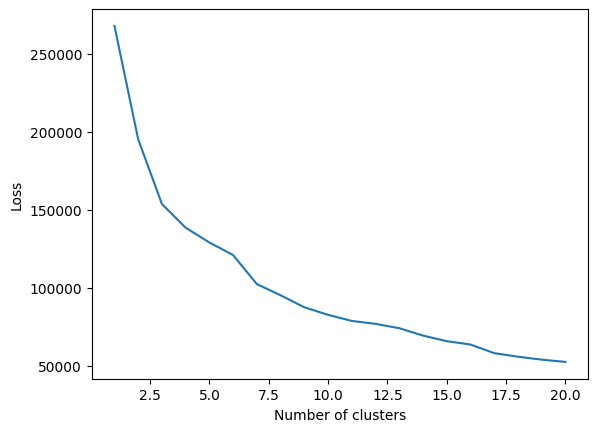

In [112]:
plt.plot(clusters, losses)
plt.ylabel("Loss")
plt.xlabel("Number of clusters")
plt.xlim()

The optimal number of clusters is identified at the "elbow point", where the rate of decrease in loss slows down significantly. From the plot, it appears that there is a significant drop in loss initially and slows down at around 2. The range of optimal number clusters seems to be around 2 to 11.

We started with plotting seven clusters to get a feeling for the result:

In [113]:
# refit algorithm
seven_means = KMeans(n_clusters=7, n_init='auto', random_state=42)
seven_means.fit(clustering_scaled_df)
seven_means.predict(clustering_scaled_df)

array([5, 4, 0, ..., 3, 3, 3], dtype=int32)

/Users/dc/Library/Caches/pypoetry/virtualenvs/aa-team-assignment-CRfD5Dnf-py3.11/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


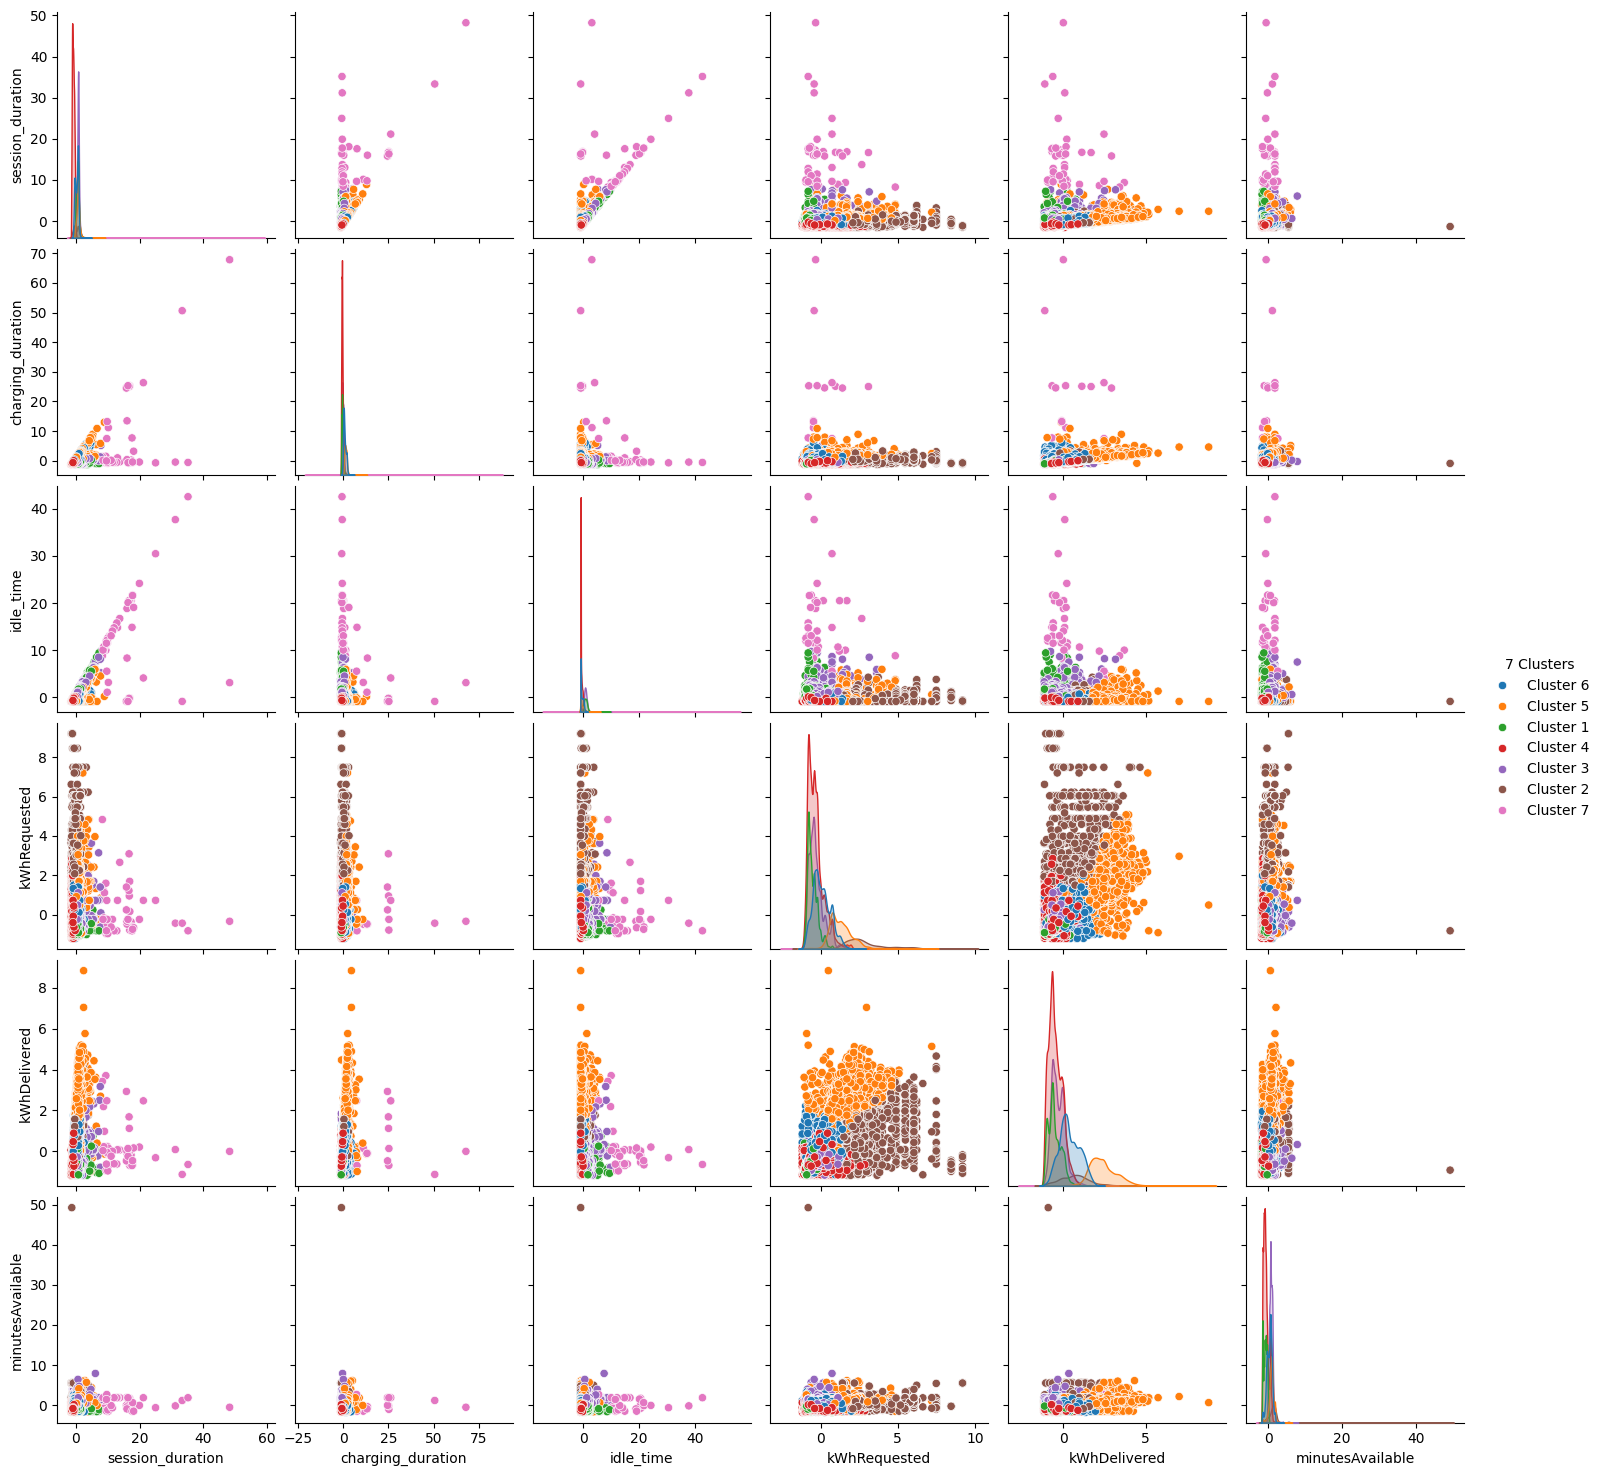

In [114]:
numbers = ["Cluster 1", "Cluster 2", "Cluster 3", "Cluster 4", "Cluster 5", "Cluster 6", "Cluster 7"]

clustering_scaled_df["7 Clusters"] = seven_means.predict(clustering_scaled)
clustering_scaled_df["7 Clusters"] = clustering_scaled_df["7 Clusters"].apply(lambda x: numbers[x])
sns.pairplot(data=clustering_scaled_df, hue="7 Clusters")

Despite seven clusters being in the range of an optimal number, with all these data dimensions we cannot provide a solid explanation. Moreover providing the management with an understandable visualisation would not be possible. Thus, we decided to reduce the dimensionality. PCA is a valid method to reduce dimensionality, but at first we tried to find reasonable criteria to exclude data dimensions. Therefore we looked at correlations between data, since highly correlated data mostly does not change the assignment of clusters. In addition, we still can explain impacts of excluded columns if a correlated column is used in clustering. 

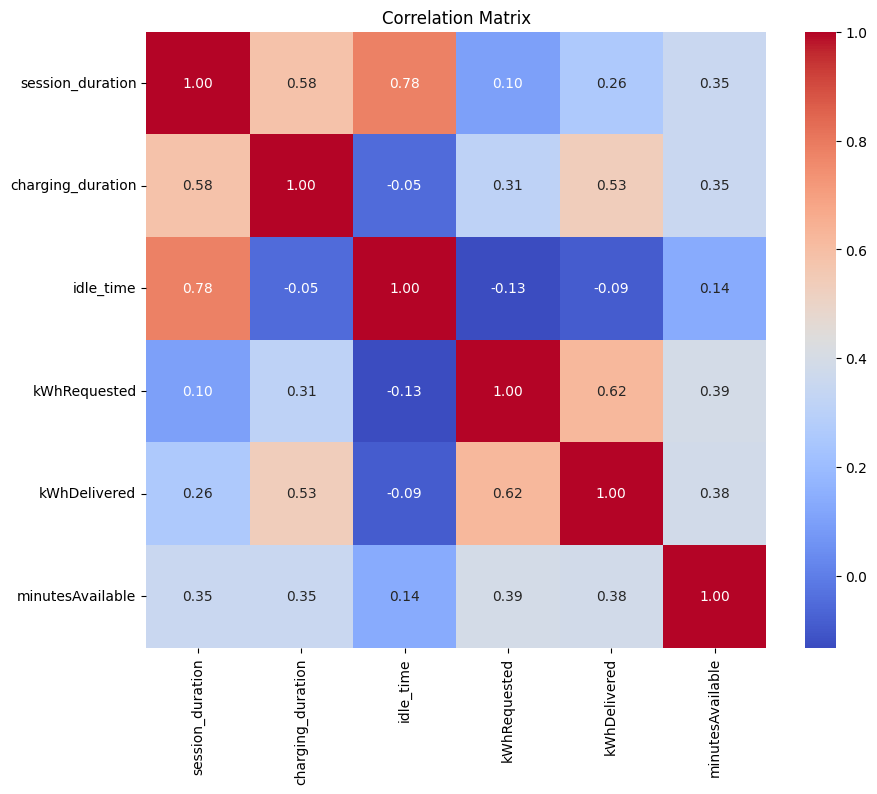

In [115]:
# Correlation Matrix Heatmap
correlation_matrix = full_charging_df[relevantFeatures].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

*charging_duration* and *idle_time* have a medium to high correlation to *session_duration*. Thus, we excluded these columns. Moreover, we decided to exclude *kWhRequested* and *minutesAvailable*, since these features are only arbitrary estimates of users and do not necessarily represent actual charging sessions. 

The two remaining dimensions are therefore: 
*session_duration* and *kWhDelivered*, which also have a relatively low correlation to each other.

In the next steps we performed the same clustering steps on these two dimensions.

In [116]:
features = [
    'session_duration',
    'kWhDelivered'
]

In [117]:
# Drop rows with NaN values
X = full_charging_df[features].dropna()

# Compare sizes before and after dropping NaNs
print(full_charging_df[features].shape)
print(X.shape)

X.head()

(60921, 2)
(60921, 2)


,session_duration,kWhDelivered
0,362.350000,25.016
1,541.516667,33.097
2,642.783333,6.521
3,158.683333,2.355
4,488.650000,13.375


In [118]:
scaler = StandardScaler()
scaler.fit(X)
clustering_scaled = scaler.transform(X)
clustering_scaled_df = pd.DataFrame(clustering_scaled, columns=X.columns, index=X.index)
clustering_scaled_df.head()

,session_duration,kWhDelivered
0,-0.068737,1.322509
1,0.538972,2.118370
2,0.882455,-0.498978
3,-0.759547,-0.909269
4,0.359656,0.176041


In [119]:
k_max = 15
clusters = []
losses = []

for k in range(k_max):
    model = KMeans(n_clusters=k+1, n_init='auto', random_state=42)
    model.fit(clustering_scaled_df)
    clusters.append(k+1)
    losses.append(model.inertia_)

(0.0, 14.0)

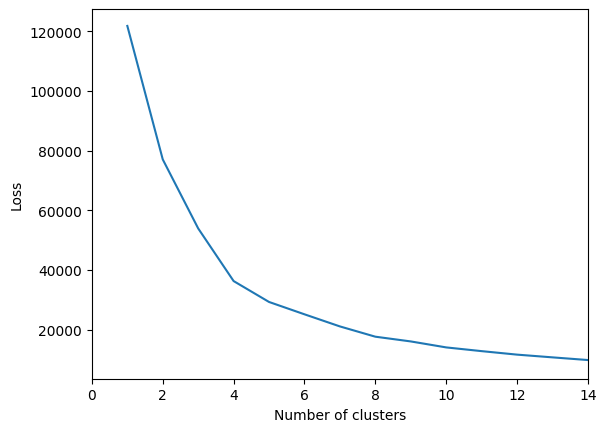

In [120]:
# Plot the loss curve to find the optimal number of clusters
plt.plot(clusters, losses)
plt.ylabel("Loss")
plt.xlabel("Number of clusters")
plt.xlim([0,14])

This plot shows that the optimal number of cluster is now reduced to between 2 and 8. We started with a five cluster approach. If we get decent clusters with this approach we could try again with more clusters. If the explainability of the clusters is bad, we can try to reduce the number of clusters.

In [121]:
numbers = ["Cluster 1", "Cluster 2", "Cluster 3", "Cluster 4", "Cluster 5"]

/Users/dc/Library/Caches/pypoetry/virtualenvs/aa-team-assignment-CRfD5Dnf-py3.11/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


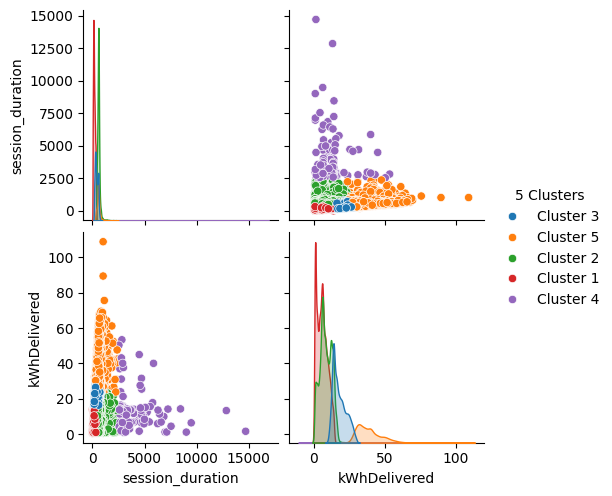

In [122]:
# Test with 5 clusters first

five_means = KMeans(n_clusters=5, n_init='auto', random_state=42)
# Fit algorithm for 5 clusters
five_means.fit(clustering_scaled_df)
X["5 Clusters"] = five_means.predict(clustering_scaled)
X["5 Clusters"] = X["5 Clusters"].apply(lambda x: numbers[x])
sns.pairplot(data=X, hue="5 Clusters")

Here, *Cluster 1* and *Cluster 3* are very close together, with *Cluster 3* having slightly more delivered kWh, but not as much as *Cluster 5*. The benefit of differentiating between *Cluster 1* and *Cluster 3* is small, since it does not provide much more explainability for the data. Because of that we decided to try again with four clusters.

/Users/dc/Library/Caches/pypoetry/virtualenvs/aa-team-assignment-CRfD5Dnf-py3.11/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


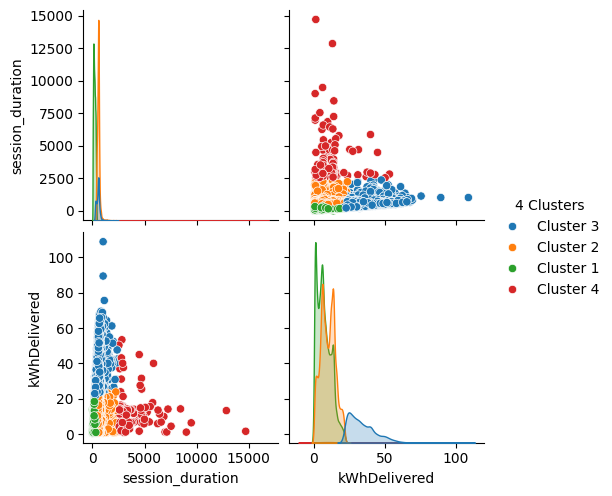

In [123]:
four_means = KMeans(n_clusters=4, n_init='auto', random_state=42)
# Fit algorithm for 4 clusters
four_means.fit(clustering_scaled_df)
X["4 Clusters"] = four_means.predict(clustering_scaled)
X["4 Clusters"] = X["4 Clusters"].apply(lambda x: numbers[x])
sns.pairplot(data=X, hue="4 Clusters")

Four clusters offer an adequate level of explainability with the following descriptions of the clusters:

#### **Cluster Description**
- **Cluster 1: Quick Session** -> Short charging time with relatively low energy consumption </p>
- **Cluster 2: Medium Charge** -> Charging Events with a medium high *session_duration* and an average *kWh_delivered*</p>
- **Cluster 3: Power Charge** -> Uses the highest amount of energy, but are connected within a regular session duration</p>
- **Cluster 4: Long Idle** -> Stay connected for a long duration, but do not charge the whole time</p>


Reducing the cluster size even further would mean loosing a valuable cluster. Thus, we decided to stay with four clusters. 

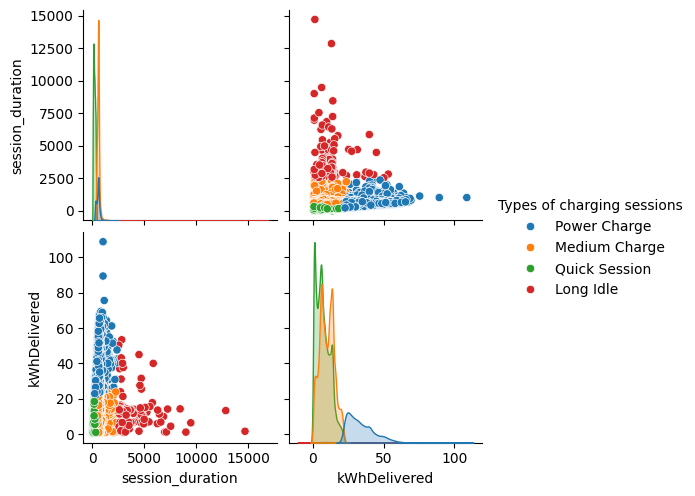

In [124]:
# Rename labels in plot

# New labels
new_mappings = {
    "Cluster 1": "Quick Session",
    "Cluster 2": "Medium Charge",
    "Cluster 3": "Power Charge",
    "Cluster 4": "Long Idle"
}

# Replace cluster names based on the mapping
charging_session_types = "Types of charging sessions"
X[charging_session_types] = X["4 Clusters"].replace(new_mappings)

# Plot with the new labels
sns.pairplot(data=X, hue=charging_session_types)


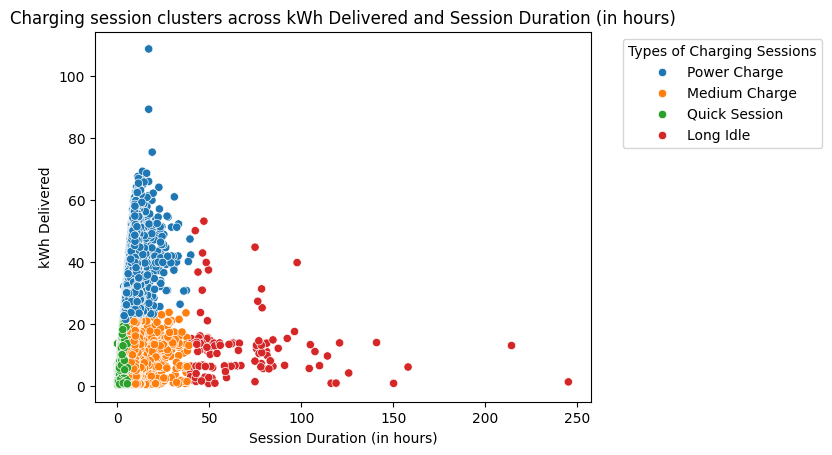

In [125]:
# Transform the session_duration to hours for easier readability
X["session_duration"] = X["session_duration"] / 60

# Final plot
sns.scatterplot(data=X, x='session_duration', y='kWhDelivered', hue=charging_session_types)
plt.title('Charging session clusters across kWh Delivered and Session Duration (in hours)')
plt.xlabel('Session Duration (in hours)')
plt.ylabel('kWh Delivered')
plt.legend(title='Types of Charging Sessions', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

We displayed the value counts for each cluster to get a feeling on how large the clusters actually are. Most fall into the *Quick Session* and *Medium Charge* clusters. Also a significant portion can be assigned to the *Power Charge* cluster, while a very small number lies in the *Long Idle* cluster.

Types of charging sessions
Quick Session    27603
Medium Charge    25668
Power Charge      7528
Long Idle          122
Name: count, dtype: int64


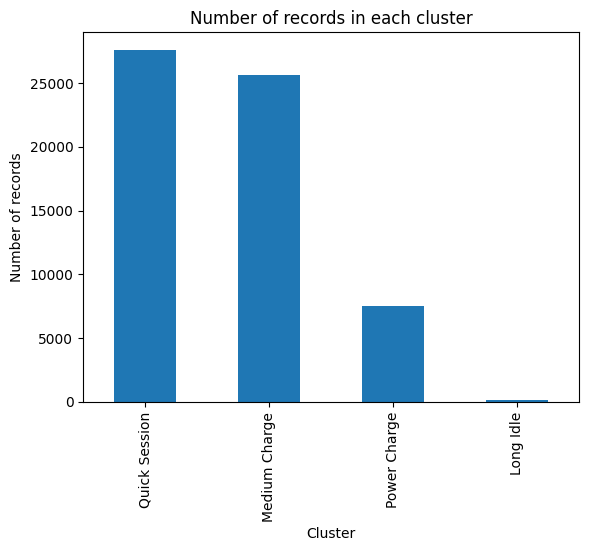

In [126]:
# Length of each cluster
print(X[charging_session_types].value_counts())

# Bar Chart plot
X[charging_session_types].value_counts().plot(kind='bar')
plt.title("Number of records in each cluster")
plt.ylabel("Number of records")
plt.xlabel("Cluster")
plt.show()

Noticable is a very low number of *Long Idle* sessions, which means that those sessions are mostly outliers. We could argue that therefore this cluster does not represent a typical charging session, but the insights that result from the existance of this cluster justifies keeping it. An insight could be, that specific users dominantly perform *Long Idle* charging sessions resulting in an inefficent utilization of the site.

In [127]:
# kWhDelivered statistics for each cluster
X.groupby(charging_session_types)["kWhDelivered"].describe()

,count,mean,std,min,25%,50%,75%,max
Types of charging sessions,,,,,,,,
Long Idle,122.0,12.247177,10.210641,0.896,6.44975,11.2600,13.9825,53.282000
Medium Charge,25668.0,9.837498,5.024752,0.506,5.90375,9.6880,13.6170,23.871000
Power Charge,7528.0,33.719568,9.260238,21.260,26.11600,31.6935,39.7480,108.797242
Quick Session,27603.0,7.176008,4.932431,0.501,3.08050,6.2710,10.6725,22.430000


In [128]:
# session_duration statistics for each cluster
X.groupby(charging_session_types)["session_duration"].describe()

,count,mean,std,min,25%,50%,75%,max
Types of charging sessions,,,,,,,,
Long Idle,122.0,68.611275,32.281801,39.076389,47.182708,60.333056,79.110556,245.269167
Medium Charge,25668.0,9.239110,2.384263,4.830556,8.016111,9.149167,10.009444,38.860556
Power Charge,7528.0,8.507939,3.095626,3.230000,6.409444,8.766528,9.816944,39.900000
Quick Session,27603.0,2.859129,1.572048,0.050833,1.550000,2.705278,4.094583,6.791111


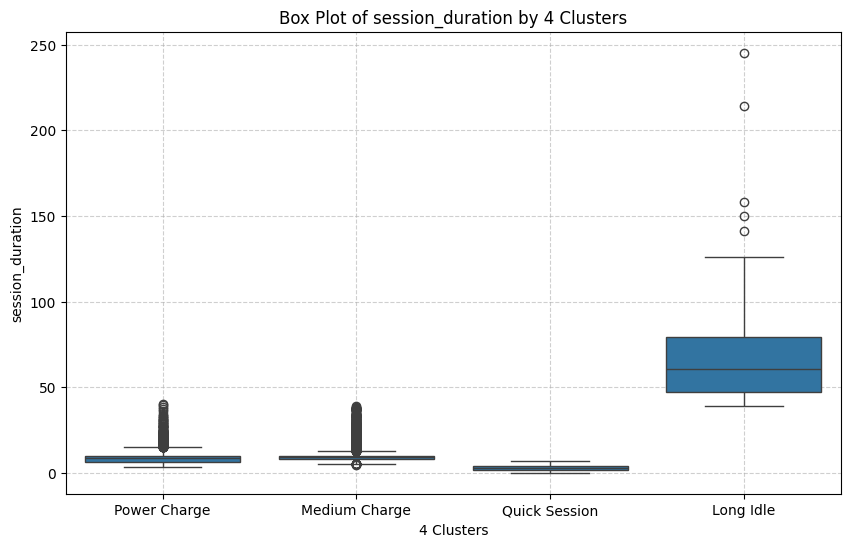

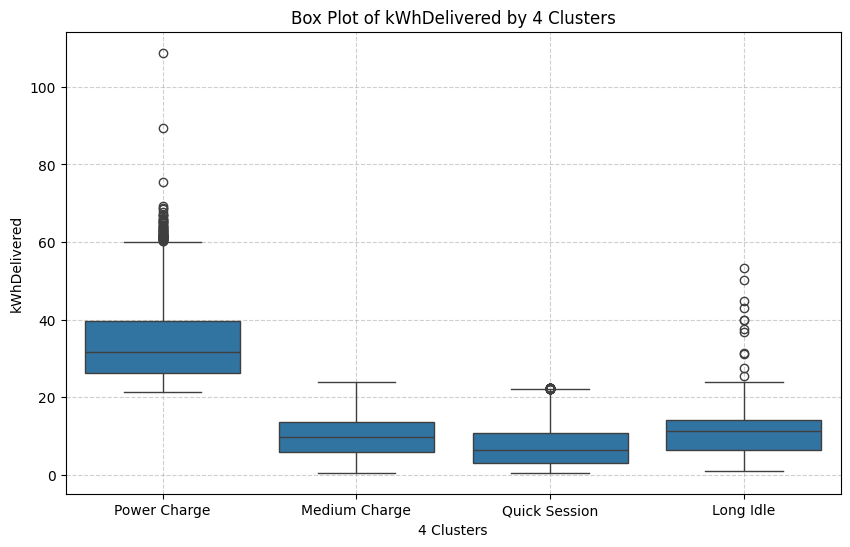

In [129]:
# Box Whisker plot
for feature in features:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=X, x=charging_session_types, y=feature)
    plt.title(f'Box Plot of {feature} by 4 Clusters')
    plt.xlabel('4 Clusters')
    plt.ylabel(feature)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

These plots additionally show key information from the clusters. *Long Idle* and *Quick Session* are mostly differentiated by the session duration, while *Power Charge* and *Medium Charge* mostly differ on the delivered kWh 

In [130]:
# Distribution of kWhDelivered and session_duration for the whole dataset
X[features].describe()

,session_duration,kWhDelivered
count,60921.000000,60921.000000
mean,6.376920,11.587520
std,4.913759,10.153871
min,0.050833,0.501000
25%,2.974167,5.018000
50%,6.308333,8.995000
75%,9.240833,13.984000
max,245.269167,108.797242


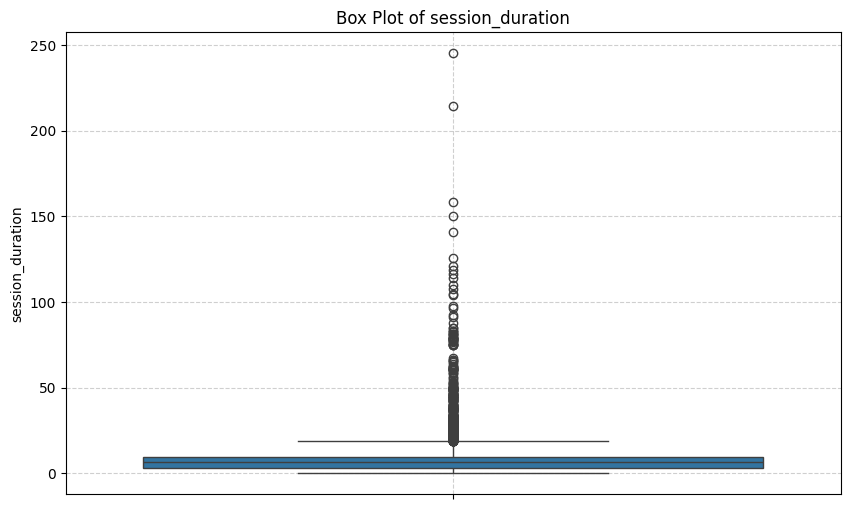

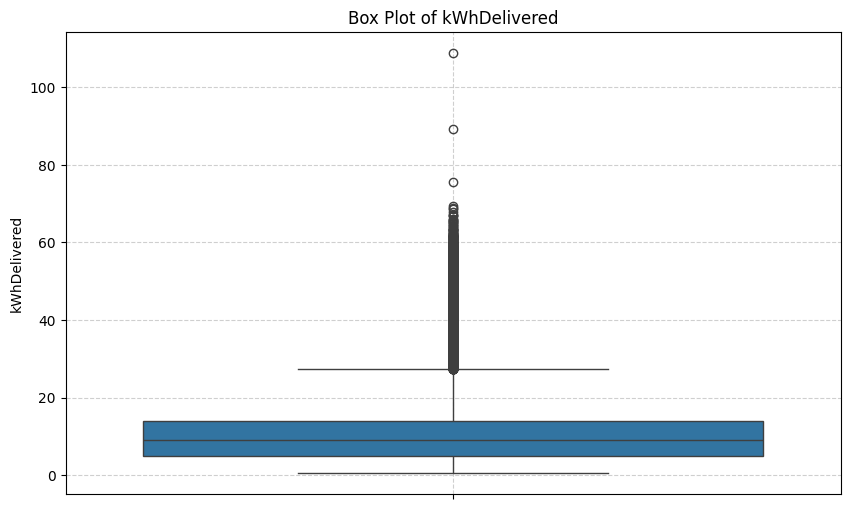

In [131]:
# Box Whisker plot
for feature in features:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=X, y=feature)
    plt.title(f'Box Plot of {feature}')
    plt.ylabel(feature)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

Because of the size of the dataset, we also have a large number of outliers for both data dimensions. Additionally, these plots can be used to compare them with the box-whisker plots from the clusters and see how the clusters differ from the overall data. This was used to elaborate the description of the clusters.

In [132]:
# user_df is the same as full charging df but the columns are dropped where the features are nan
# user_df is specified here for merging the userIDs back to the clusters dataframe in the next steps
user_df = full_charging_df.dropna(subset=features)
print(X.shape)
print(user_df.shape)

(60921, 5)
(60921, 36)


As an additional step we noticed, that we can assign a dominant cluster to all registered users. To have solid assignments we decided to only include users with at least 5 valid charging sessions

In [133]:
# Append clusters column to user_df
user_df[charging_session_types] = X[charging_session_types]

# Group by userID and calculate session count
user_session_counts = user_df.groupby('userID').size()

# Filter users with at least 5 sessions
valid_user_ids = user_session_counts[user_session_counts >= 5].index
user_df = user_df[user_df['userID'].isin(valid_user_ids)]
user_df['userID'].nunique()

631

In [134]:
# Check cluster consistency for each userID
user_cluster_stats = (
    user_df.groupby('userID')[charging_session_types]
    .value_counts(normalize=True)  # Get proportion of sessions in each cluster
    .reset_index(name='proportion')
)

user_cluster_stats

,userID,Types of charging sessions,proportion
0,22.0,Medium Charge,0.368421
1,22.0,Quick Session,0.350877
2,22.0,Power Charge,0.280702
3,58.0,Power Charge,0.800000
4,58.0,Quick Session,0.200000
...,...,...,...
1416,17953.0,Quick Session,0.833333
1417,17953.0,Medium Charge,0.166667
1418,18886.0,Power Charge,0.400000
1419,18886.0,Quick Session,0.400000


Furthermore, we define that a user only has a dominant cluster assigned, if at least 80% of his charging sessions belong to that cluster.
This results in approximately 40% of the valid registered users to also have a dominant cluster assigned.

In [135]:
# Find the dominant cluster for each user
dominant_clusters = user_cluster_stats.loc[user_cluster_stats.groupby('userID')['proportion'].idxmax()].reset_index(drop=True)

# Only keep users where the dominant cluster is more than 80% of their sessions
dominant_clusters = dominant_clusters[dominant_clusters['proportion'] >= 0.8]

# Percentage of users with a dominant cluster
percentage_dominant = dominant_clusters.shape[0] / user_df['userID'].nunique() * 100
print(f"Percentage of users with a dominant cluster: {percentage_dominant:.2f}%")

# Rename the columns for clarity
dominant_clusters = dominant_clusters.rename(columns={charging_session_types: 'dominant_cluster', 'proportion': 'consistency_score'})

dominant_clusters

Percentage of users with a dominant cluster: 40.25%


,userID,dominant_cluster,consistency_score
1,58.0,Power Charge,0.800000
2,61.0,Medium Charge,0.837209
4,67.0,Power Charge,0.803571
6,69.0,Medium Charge,0.815789
7,76.0,Quick Session,0.963158
...,...,...,...
621,15756.0,Quick Session,1.000000
623,16140.0,Medium Charge,1.000000
626,17097.0,Quick Session,0.800000
628,17752.0,Medium Charge,1.000000


In [136]:
# Calculate the total number of users
total_users = dominant_clusters['dominant_cluster'].value_counts().sum()
print(total_users)

# Add a percentage column
cluster_counts = dominant_clusters['dominant_cluster'].value_counts().reset_index()
cluster_counts.columns = ['dominant_cluster', 'count']
cluster_counts['percentage'] = (cluster_counts['count'] / total_users) * 100
cluster_counts

254


,dominant_cluster,count,percentage
0,Quick Session,130,51.181102
1,Medium Charge,91,35.826772
2,Power Charge,33,12.992126


Insights from the dominant clusters analysis:
- Most can be identified as *Quick Session* & *Medium Charge*
- Currently no user has the *Long Idle* cluster as the dominant one, probably because these events only occur rarely
- *Power Charges* are the minority -> Could be interesting for a business case to charge premium prices for these users

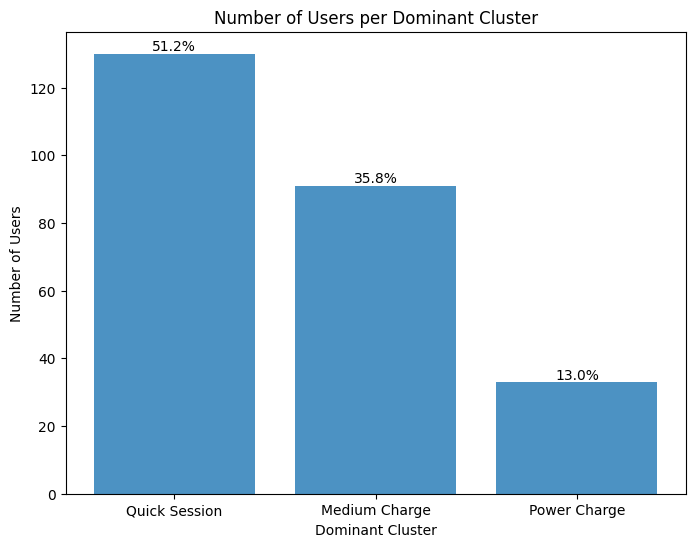

In [137]:
# Plot the counts
plt.figure(figsize=(8, 6))
plt.bar(cluster_counts['dominant_cluster'], cluster_counts['count'], alpha=0.8, label='Count')

# Add percentages on top of the bars
for i, row in cluster_counts.iterrows():
    plt.text(row['dominant_cluster'], row['count'], f"{row['percentage']:.1f}%", ha='center', va='bottom')

# Add labels and title
plt.xlabel('Dominant Cluster')
plt.ylabel('Number of Users')
plt.title('Number of Users per Dominant Cluster')
plt.show()

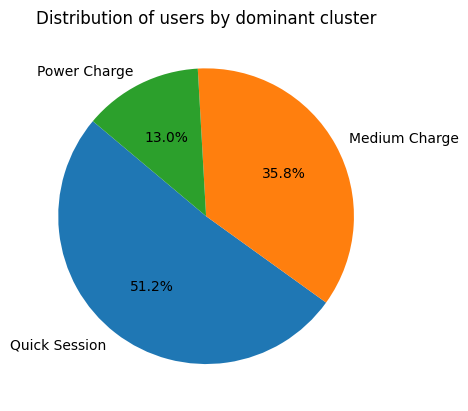

In [138]:
# Pie chart
plt.pie(cluster_counts['percentage'], labels=cluster_counts['dominant_cluster'], autopct='%1.1f%%', startangle=140)
plt.title('Distribution of users by dominant cluster')
plt.show()